
Author: Prof. Manoel Gadi

Contact: mfalonso@faculty.ie.edu

Teaching Web: https://github.com/manoelgadi

Last revision: 10/May/2026

# Stress Testing with Monte Carlo Simulation for Banks

This notebook demonstrates a simplified banking stress testing framework using Monte Carlo simulation.

The goal is to show how a bank can estimate:

- **PD**: Probability of Default
- **LGD**: Loss Given Default
- **EAD**: Exposure at Default
- **Expected Loss / Provision**
- **Profitability after provision**
- **Stress testing under macroeconomic shocks**
- **Expected and unexpected losses**

The framework follows the classic credit risk formula:

$$Expected\ Loss = PD \times LGD \times EAD$$

This is a teaching example, not a production regulatory model.

## 1. Import Libraries

We start by importing the Python libraries needed for data simulation, modeling, evaluation, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import roc_auc_score, mean_absolute_error

np.random.seed(42)

## 2. Create a Synthetic Banking Credit Portfolio

We create a synthetic portfolio of bank customers.

Each customer has financial and behavioral characteristics such as income, credit score, debt-to-income ratio, loan amount, interest rate, tenure, and regional unemployment.

These variables will later be used to model PD, LGD, and EAD.

In [2]:
n = 10000

df = pd.DataFrame({
    "customer_id": range(1, n + 1),
    "age": np.random.randint(18, 75, n),
    "income": np.random.normal(45000, 15000, n).clip(10000, 150000),
    "credit_score": np.random.normal(680, 80, n).clip(300, 850),
    "debt_to_income": np.random.beta(2, 5, n).clip(0, 1),
    "loan_amount": np.random.normal(15000, 7000, n).clip(1000, 60000),
    "interest_rate": np.random.normal(0.08, 0.025, n).clip(0.02, 0.25),
    "tenure_years": np.random.randint(0, 15, n),
    "unemployment_region": np.random.normal(0.08, 0.025, n).clip(0.02, 0.25)
})

df.head()

,customer_id,age,income,credit_score,debt_to_income,loan_amount,interest_rate,tenure_years,unemployment_region
0,1,56,30181.010881,630.558708,0.329125,10589.877682,0.061503,14,0.107189
1,2,69,45965.588563,734.362848,0.373430,14947.410665,0.069133,14,0.087389
2,3,46,18293.142720,605.596542,0.465357,12867.386306,0.056094,9,0.104418
3,4,32,50115.577658,647.550016,0.343630,10673.874768,0.100914,11,0.096123
4,5,60,20530.882566,531.666284,0.223865,19700.430833,0.078812,10,0.072435


## 3. Create the PD Target

PD means **Probability of Default**.

In this synthetic example, default risk increases when credit score is lower, debt-to-income ratio is higher, income is lower, and regional unemployment is higher.

We create a hidden true default probability and then simulate whether the customer defaults or not.

In [3]:
pd_score = (
    -0.010 * df["credit_score"]
    + 2.5 * df["debt_to_income"]
    - 0.000015 * df["income"]
    + 4.0 * df["unemployment_region"]
    + np.random.normal(0, 0.7, n)
)

df["true_pd"] = 1 / (1 + np.exp(-pd_score))
df["default"] = np.random.binomial(1, df["true_pd"])

df[["customer_id", "true_pd", "default"]].head()

,customer_id,true_pd,default
0,1,0.008950,0
1,2,0.000594,0
2,3,0.007393,0
3,4,0.009414,0
4,5,0.023846,0


## 4. Create the LGD Target

LGD means **Loss Given Default**.

It represents the percentage of exposure that the bank loses if the customer defaults.

For example, if EAD is €10,000 and LGD is 40%, then the bank loses:

$$10,000 \times 40\% = 4,000$$

In this synthetic example, LGD increases with higher debt-to-income and higher unemployment.

In [4]:
df["true_lgd"] = (
    0.25
    + 0.40 * df["debt_to_income"]
    - 0.000002 * df["income"]
    + 0.20 * df["unemployment_region"]
    + np.random.normal(0, 0.08, n)
).clip(0.05, 0.95)

df[["customer_id", "true_lgd"]].head()

,customer_id,true_lgd
0,1,0.353045
1,2,0.341528
2,3,0.527761
3,4,0.340420
4,5,0.282014


## 5. Create the EAD Target

EAD means **Exposure at Default**.

It represents how much money is still exposed if the customer defaults.

In this example, EAD is related to the original loan amount, but includes some randomness.

In [5]:
df["true_ead"] = (
    df["loan_amount"]
    * np.random.normal(0.85, 0.10, n)
).clip(500, df["loan_amount"])

df[["customer_id", "loan_amount", "true_ead"]].head()

,customer_id,loan_amount,true_ead
0,1,10589.877682,9495.786520
1,2,14947.410665,12358.092599
2,3,12867.386306,11463.639603
3,4,10673.874768,9204.746213
4,5,19700.430833,19571.675040


## 6. Select Model Features

We now define the explanatory variables used by the PD, LGD, and EAD models.

In real banking, feature selection would require careful validation, governance, explainability, and fairness checks.

In [6]:
features = [
    "age", "income", "credit_score", "debt_to_income",
    "loan_amount", "interest_rate", "tenure_years",
    "unemployment_region"
]

X = df[features]

## 7. Train the PD Model

The PD model is a classification model.

It predicts whether a customer is likely to default.

We use a Random Forest classifier and evaluate it using AUC.

In [7]:
y_pd = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_pd, test_size=0.3, random_state=42
)

pd_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

pd_model.fit(X_train, y_train)

df["predicted_pd"] = pd_model.predict_proba(X)[:, 1]

pd_auc = roc_auc_score(y_test, pd_model.predict_proba(X_test)[:, 1])

print("PD Model AUC:", round(pd_auc, 4))

df[["customer_id", "predicted_pd"]].head()

PD Model AUC: 0.6132


,customer_id,predicted_pd
0,1,0.000679
1,2,0.000579
2,3,0.001439
3,4,0.000186
4,5,0.005540


## 8. Train the LGD Model

The LGD model is a regression model.

It predicts the percentage loss if the customer defaults.

We evaluate the model using Mean Absolute Error.

In [8]:
y_lgd = df["true_lgd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_lgd, test_size=0.3, random_state=42
)

lgd_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

lgd_model.fit(X_train, y_train)

df["predicted_lgd"] = lgd_model.predict(X).clip(0, 1)

lgd_mae = mean_absolute_error(y_test, lgd_model.predict(X_test))

print("LGD Model MAE:", round(lgd_mae, 4))

df[["customer_id", "predicted_lgd"]].head()

LGD Model MAE: 0.0637


,customer_id,predicted_lgd
0,1,0.358823
1,2,0.316230
2,3,0.427273
3,4,0.302435
4,5,0.315151


## 9. Train the EAD Model

The EAD model is also a regression model. It predicts the amount of money exposed if the customer defaults.

In [9]:
y_ead = df["true_ead"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_ead, test_size=0.3, random_state=42
)

ead_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

ead_model.fit(X_train, y_train)

df["predicted_ead"] = ead_model.predict(X).clip(0, df["loan_amount"])

ead_mae = mean_absolute_error(y_test, ead_model.predict(X_test))

print("EAD Model MAE:", round(ead_mae, 2))

df[["customer_id", "predicted_ead"]].head()

EAD Model MAE: 1190.21


,customer_id,predicted_ead
0,1,9192.523940
1,2,12358.612408
2,3,10954.372657
3,4,9201.738991
4,5,17266.790438


## 10. Calculate Expected Loss and Provision

The expected loss formula is:

$$Expected\ Loss = PD \times LGD \times EAD$$

In banking, this expected loss is closely related to the concept of provision: the amount the bank sets aside to cover expected credit losses.

In [10]:
df["expected_loss"] = (
    df["predicted_pd"]
    * df["predicted_lgd"]
    * df["predicted_ead"]
)

df[["customer_id", "predicted_pd", "predicted_lgd", "predicted_ead", "expected_loss"]].head()

,customer_id,predicted_pd,predicted_lgd,predicted_ead,expected_loss
0,1,0.000679,0.358823,9192.523940,2.239073
1,2,0.000579,0.316230,12358.612408,2.262697
2,3,0.001439,0.427273,10954.372657,6.736479
3,4,0.000186,0.302435,9201.738991,0.518750
4,5,0.005540,0.315151,17266.790438,30.147149


## 11. Calculate Profitability After Provision

We create a simple profitability measure:

$$Profit\ After\ Provision = Interest\ Income - Expected\ Loss$$

This allows us to connect credit risk to profitability.

In [11]:
df["interest_income"] = df["loan_amount"] * df["interest_rate"]

df["profit_after_provision"] = (
    df["interest_income"] - df["expected_loss"]
)

portfolio_summary = pd.DataFrame({
    "Total Loan Amount": [df["loan_amount"].sum()],
    "Total Interest Income": [df["interest_income"].sum()],
    "Total Provision / Expected Loss": [df["expected_loss"].sum()],
    "Profit After Provision": [df["profit_after_provision"].sum()]
})

portfolio_summary

,Total Loan Amount,Total Interest Income,Total Provision / Expected Loss,Profit After Provision
0,1.502960e+08,1.201625e+07,123813.073312,1.189244e+07


## 12. Monte Carlo Stress Testing

Monte Carlo simulation means running many possible future scenarios.

In each simulation, we generate random shocks to unemployment, income, and collateral / recovery conditions.

Then we recalculate stressed PD, LGD, EAD, expected loss, and profitability.

In [12]:
n_simulations = 5000

simulation_results = []

for i in range(n_simulations):

    # Simulate macroeconomic stress
    unemployment_shock = np.random.normal(0.00, 0.03)
    income_shock = np.random.normal(0.00, 0.05)
    collateral_shock = np.random.normal(0.00, 0.08)

    stressed_df = df.copy()

    stressed_df["stressed_unemployment"] = (
        stressed_df["unemployment_region"] + unemployment_shock
    ).clip(0.01, 0.40)

    stressed_df["stressed_income"] = (
        stressed_df["income"] * (1 - income_shock)
    ).clip(5000, 150000)

    # Stressed PD: unemployment and income deterioration increase default risk
    stressed_pd = (
        stressed_df["predicted_pd"]
        * (1 + 5 * unemployment_shock)
        * (1 + 2 * income_shock)
    ).clip(0, 1)

    # Stressed LGD: collateral deterioration increases loss severity
    stressed_lgd = (
        stressed_df["predicted_lgd"]
        * (1 + 2 * collateral_shock)
    ).clip(0, 1)

    # Stressed EAD: under stress, customers may use more credit lines
    stressed_ead = (
        stressed_df["predicted_ead"]
        * (1 + np.random.normal(0.02, 0.05))
    ).clip(0, stressed_df["loan_amount"])

    stressed_expected_loss = (
        stressed_pd * stressed_lgd * stressed_ead
    ).sum()

    stressed_interest_income = stressed_df["interest_income"].sum()

    stressed_profit = stressed_interest_income - stressed_expected_loss

    simulation_results.append({
        "simulation": i + 1,
        "unemployment_shock": unemployment_shock,
        "income_shock": income_shock,
        "collateral_shock": collateral_shock,
        "expected_loss": stressed_expected_loss,
        "profit_after_provision": stressed_profit
    })

stress_results = pd.DataFrame(simulation_results)

stress_results.head()

,simulation,unemployment_shock,income_shock,collateral_shock,expected_loss,profit_after_provision
0,1,0.006146,0.017127,-0.087435,117510.602739,1.189874e+07
1,2,0.015662,-0.038397,-0.138762,89774.186135,1.192648e+07
2,3,0.016414,-0.068162,-0.202394,69996.785586,1.194626e+07
3,4,-0.019787,-0.065993,-0.049214,89539.668327,1.192672e+07
4,5,-0.033580,0.100466,0.038675,143584.711516,1.187267e+07


## 13. Expected Loss and Unexpected Loss

Expected Loss is the average loss the bank expects.

Unexpected Loss is the additional loss that can happen in bad scenarios.

Here we estimate baseline expected loss, mean stressed expected loss, 95th percentile loss, and 99th percentile loss.

In [13]:
baseline_expected_loss = df["expected_loss"].sum()

mean_stressed_loss = stress_results["expected_loss"].mean()
unexpected_loss_95 = np.percentile(stress_results["expected_loss"], 95)
unexpected_loss_99 = np.percentile(stress_results["expected_loss"], 99)

summary_stress = pd.DataFrame({
    "Metric": [
        "Baseline Expected Loss",
        "Mean Stressed Expected Loss",
        "Unexpected Loss 95%",
        "Unexpected Loss 99%"
    ],
    "Value": [
        baseline_expected_loss,
        mean_stressed_loss,
        unexpected_loss_95,
        unexpected_loss_99
    ]
})

summary_stress

,Metric,Value
0,Baseline Expected Loss,123813.073312
1,Mean Stressed Expected Loss,126191.276404
2,Unexpected Loss 95%,181084.321762
3,Unexpected Loss 99%,208474.038087


## 14. Plot the Distribution of Portfolio Losses

This histogram shows the simulated distribution of expected losses under different stress scenarios.

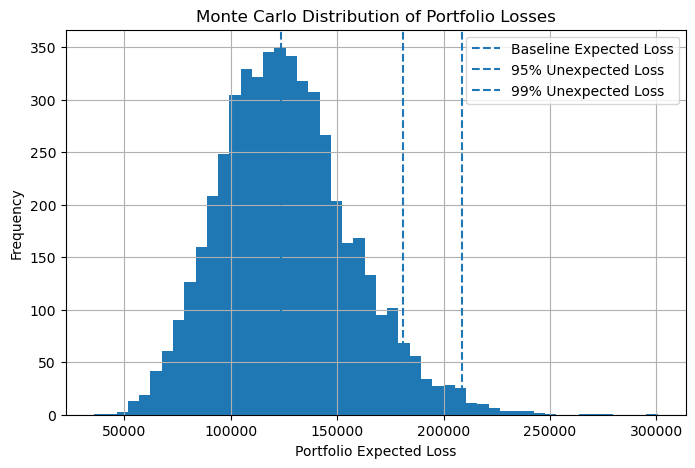

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(stress_results["expected_loss"], bins=50)
plt.axvline(baseline_expected_loss, linestyle="--", label="Baseline Expected Loss")
plt.axvline(unexpected_loss_95, linestyle="--", label="95% Unexpected Loss")
plt.axvline(unexpected_loss_99, linestyle="--", label="99% Unexpected Loss")
plt.xlabel("Portfolio Expected Loss")
plt.ylabel("Frequency")
plt.title("Monte Carlo Distribution of Portfolio Losses")
plt.legend()
plt.grid(True)
plt.show()

## 15. Expected Loss Curve by Unemployment Shock

This chart shows how expected loss changes as the unemployment shock becomes more severe.

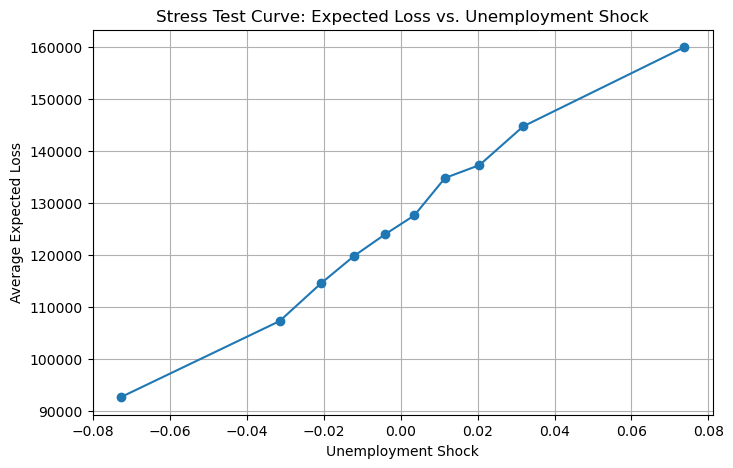

In [15]:
stress_results["unemployment_bucket"] = pd.qcut(
    stress_results["unemployment_shock"],
    q=10,
    duplicates="drop"
)

loss_curve = (
    stress_results
    .groupby("unemployment_bucket", observed=False)["expected_loss"]
    .mean()
    .reset_index()
)

loss_curve["bucket_midpoint"] = loss_curve["unemployment_bucket"].apply(lambda x: x.mid)

plt.figure(figsize=(8, 5))
plt.plot(loss_curve["bucket_midpoint"], loss_curve["expected_loss"], marker="o")
plt.xlabel("Unemployment Shock")
plt.ylabel("Average Expected Loss")
plt.title("Stress Test Curve: Expected Loss vs. Unemployment Shock")
plt.grid(True)
plt.show()

## 16. Profitability Under Stress

Stress testing is not only about losses. It is also about understanding how profitability changes when provisions increase.

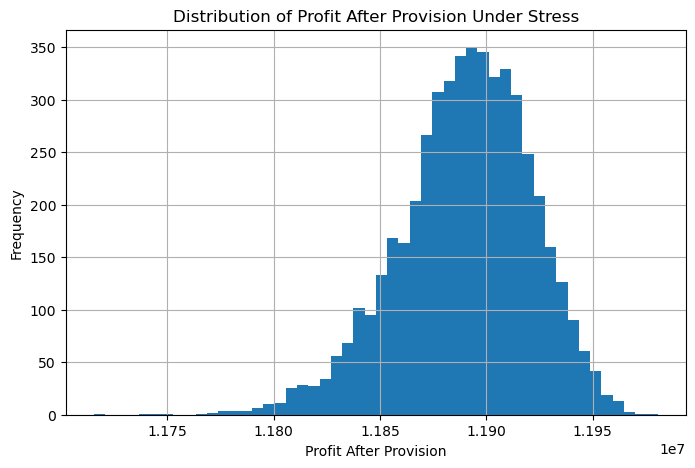

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(stress_results["profit_after_provision"], bins=50)
plt.xlabel("Profit After Provision")
plt.ylabel("Frequency")
plt.title("Distribution of Profit After Provision Under Stress")
plt.grid(True)
plt.show()

## 17. Final Stress Test Summary

The final table summarizes the key stress testing results.

In [18]:
import pandas as pd
import numpy as np

# --- ADD THIS LINE ---
# This formats floats with commas and 2 decimal places (e.g., 11,890,060.00)
pd.options.display.float_format = '{:,.2f}'.format

profit_5_percentile = np.percentile(stress_results["profit_after_provision"], 5)
profit_1_percentile = np.percentile(stress_results["profit_after_provision"], 1)

final_summary = pd.DataFrame({
    "Metric": [
        "Baseline Expected Loss",
        "Mean Stress Expected Loss",
        "95% Loss Level",
        "99% Loss Level",
        "Mean Profit After Provision",
        "5% Worst Profit Scenario",
        "1% Worst Profit Scenario"
    ],
    "Value": [
        baseline_expected_loss,
        mean_stressed_loss,
        unexpected_loss_95,
        unexpected_loss_99,
        stress_results["profit_after_provision"].mean(),
        profit_5_percentile,
        profit_1_percentile
    ]
})

final_summary

,Metric,Value
0,Baseline Expected Loss,"123,813.07"
1,Mean Stress Expected Loss,"126,191.28"
2,95% Loss Level,"181,084.32"
3,99% Loss Level,"208,474.04"
4,Mean Profit After Provision,"11,890,063.72"
5,5% Worst Profit Scenario,"11,835,170.68"
6,1% Worst Profit Scenario,"11,807,780.96"


## Final Interpretation

This notebook demonstrates the full credit risk stress testing logic:

$$PD \times LGD \times EAD = Expected\ Loss$$

Then:

$$Profitability = Interest\ Income - Provision$$

The Monte Carlo simulation allows us to see many possible future scenarios instead of just one fixed scenario.

This is useful because banks need to understand not only the average expected loss, but also how bad losses could become under adverse economic conditions.